# 03D — Item2Vec & Category-Specific Embeddings

**Experiments:**
1. Train Item2Vec on purchase sequences — behavioral embeddings learned from this dataset
2. Compare Item2Vec candidates to co-purchase candidates (recall comparison)
3. Build category-specific image/text similarity features
4. Add all new features to the ranker and measure impact

In [1]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT = '/content/drive/MyDrive/MLII_Final'

Mounted at /content/drive


In [2]:
!pip install -q gensim implicit lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 99.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 151.3 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle, time, sys
from pathlib import Path
from gensim.models import Word2Vec
from collections import Counter
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.figsize': (10, 5), 'figure.dpi': 120,
    'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 11})
PALETTE = ['#2D2D2D', '#A8C8E8', '#C4D9A0', '#D4B8E0', '#F2C4C4', '#FFD9A0', '#E8D5B7']

DATA_DIR = Path(f'{PROJECT}/data/parquet')
SPLIT_DIR = Path(f'{PROJECT}/data/split')
OUT_DIR = Path(f'{PROJECT}/outputs')
FIG_DIR = Path(f'{PROJECT}/outputs/figures')

sys.path.insert(0, f'{PROJECT}/src')
from eval import map_at_k

SPLIT_DATE = pd.Timestamp('2020-09-16')

In [4]:
# Load data
train = pd.read_parquet(SPLIT_DIR / 'train.parquet')
val = pd.read_parquet(SPLIT_DIR / 'val.parquet')
articles = pd.read_parquet(DATA_DIR / 'articles.parquet')

val_ground_truth = val.groupby('customer_id')['article_id'].apply(set).to_dict()

with open(OUT_DIR / 'baseline_data.pkl', 'rb') as f:
    baseline_data = pickle.load(f)
with open(OUT_DIR / 'candidate_sets.pkl', 'rb') as f:
    candidate_sets = pickle.load(f)
with open(OUT_DIR / 'als_scores.pkl', 'rb') as f:
    als_scores = pickle.load(f)

top_12_global = baseline_data['top_12_global']
customer_history = baseline_data['customer_history']
copurchase = baseline_data['copurchase']
age_map = baseline_data['age_map']
top_by_age = baseline_data['top_by_age']

# Load embeddings
img_emb = pd.read_parquet(OUT_DIR / 'image_embeddings.parquet')
text_emb = pd.read_parquet(OUT_DIR / 'text_embeddings.parquet')
img_emb_cols = [c for c in img_emb.columns if c.startswith('img_emb_')]
text_emb_cols = [c for c in text_emb.columns if c.startswith('text_emb_')]
img_emb_dict = dict(zip(img_emb['article_id'], img_emb[img_emb_cols].values))
text_emb_dict = dict(zip(text_emb['article_id'], text_emb[text_emb_cols].values))

article_meta = articles.set_index('article_id')[[
    'product_code', 'product_type_name', 'product_group_name',
    'department_name', 'index_group_name', 'colour_group_name'
]].to_dict('index')

print(f"Train: {len(train):,} | Val customers: {len(val_ground_truth):,}")

Train: 31,548,013 | Val customers: 68,984


---
## 1. Train Item2Vec

Item2Vec treats each customer's purchase history as a "sentence" and each
article_id as a "word." Items that appear in similar purchase contexts
(bought by the same customers, near the same other items) get similar embeddings.

Unlike ResNet-50 (which embeds what items *look like*) or sentence-transformers
(which embed what items *are described as*), Item2Vec embeds what items *mean
in terms of purchase behavior*. Two items can look completely different but
have similar Item2Vec embeddings because they're co-purchased.

In [5]:
# Build purchase sequences — each customer's history in chronological order
print("Building purchase sequences...")
t0 = time.time()

purchase_sequences = (
    train.sort_values('t_dat')
    .groupby('customer_id')['article_id']
    .apply(list)
    .tolist()
)

# Filter: skip very short sequences (< 3 items) and cap very long ones
purchase_sequences = [seq[:385] for seq in purchase_sequences if len(seq) >= 3]

print(f"Sequences: {len(purchase_sequences):,}")
print(f"Avg length: {np.mean([len(s) for s in purchase_sequences]):.1f}")
print(f"Built in {time.time()-t0:.1f}s")

Building purchase sequences...
Sequences: 1,099,105
Avg length: 28.2
Built in 47.8s


In [6]:
# Train Word2Vec (= Item2Vec)
print("Training Item2Vec...")
t0 = time.time()

item2vec = Word2Vec(
    sentences=purchase_sequences,
    vector_size=64,   # embedding dimensions
    window=5,          # context window — items within 5 positions are "co-occurring"
    min_count=5,       # ignore items purchased fewer than 5 times total
    sg=1,              # skip-gram (better for sparse, implicit data)
    workers=4,
    epochs=10,
    seed=42,
)

print(f"Trained in {time.time()-t0:.1f}s")
print(f"Vocabulary: {len(item2vec.wv):,} items with embeddings")
print(f"Embedding dims: {item2vec.wv.vector_size}")

Training Item2Vec...
Trained in 647.8s
Vocabulary: 91,027 items with embeddings
Embedding dims: 64


In [7]:
# Sanity check: nearest neighbors for a popular item
test_aid = top_12_global[0]
if test_aid in item2vec.wv:
    test_meta = article_meta.get(test_aid, {})
    print(f"Query: {test_meta.get('product_type_name', '?')} ({test_meta.get('department_name', '?')})")
    print(f"\nNearest neighbors by ITEM2VEC (behavioral similarity):")
    for aid, score in item2vec.wv.most_similar(test_aid, topn=8):
        meta = article_meta.get(aid, {})
        print(f"  sim={score:.4f}  {meta.get('product_type_name', '?')} ({meta.get('department_name', '?')}) [{meta.get('colour_group_name', '?')}]")

    # Compare to image embedding neighbors
    if test_aid in img_emb_dict:
        print(f"\nNearest neighbors by RESNET (visual similarity):")
        test_img = img_emb_dict[test_aid].reshape(1, -1)
        all_aids = list(img_emb_dict.keys())
        all_vecs = np.array([img_emb_dict[a] for a in all_aids])
        sims = (all_vecs @ test_img.T).flatten()
        top_idx = np.argsort(sims)[::-1][1:9]
        for idx in top_idx:
            aid = all_aids[idx]
            meta = article_meta.get(aid, {})
            print(f"  sim={sims[idx]:.4f}  {meta.get('product_type_name', '?')} ({meta.get('department_name', '?')}) [{meta.get('colour_group_name', '?')}]")

Query: Trousers (Trouser)

Nearest neighbors by ITEM2VEC (behavioral similarity):
  sim=0.9198  Trousers (Trouser) [Black]
  sim=0.8503  Trousers (Trouser) [Black]
  sim=0.8208  Shirt (Blouse) [Black]
  sim=0.8034  Blazer (Suit) [Black]
  sim=0.7939  Trousers (Trouser) [Dark Blue]
  sim=0.7712  Trousers (Trouser) [Dark Blue]
  sim=0.7690  Trousers (Trouser) [Dark Grey]
  sim=0.7677  Trousers (Trouser) [Black]

Nearest neighbors by RESNET (visual similarity):
  sim=0.9877  Trousers (Trouser) [Dark Blue]
  sim=0.9865  Leggings/Tights (Trousers DS) [Black]
  sim=0.9846  Leggings/Tights (Jersey Basic) [Black]
  sim=0.9840  Trousers (Trouser) [Dark Blue]
  sim=0.9838  Trousers (Trouser) [Black]
  sim=0.9837  Trousers (Trouser S&T) [Black]
  sim=0.9837  Trousers (Trouser) [Dark Blue]
  sim=0.9827  Trousers (Trouser) [Black]


---
## 2. Compare Item2Vec vs Co-Purchase as Candidate Source

For each validation customer, generate candidates from both sources and
measure which captures more actual purchases (recall).

In [8]:
recent_cutoff = SPLIT_DATE - pd.Timedelta(days=14)
recent_purchases = (
    train[train['t_dat'] >= recent_cutoff]
    .groupby('customer_id')['article_id']
    .apply(set)
    .to_dict()
)

def get_item2vec_candidates(cid, n=15):
    """Get item2vec candidates from customer's recent purchases."""
    seed_items = recent_purchases.get(cid, set())
    if not seed_items:
        # Fall back to full history
        history = customer_history.get(cid, [])
        seed_items = set(history[:10])

    candidates = {}
    for aid in seed_items:
        if aid in item2vec.wv:
            for similar_aid, score in item2vec.wv.most_similar(aid, topn=10):
                if similar_aid not in seed_items:
                    candidates[similar_aid] = max(candidates.get(similar_aid, 0), score)
    return sorted(candidates, key=candidates.get, reverse=True)[:n]

def get_copurchase_candidates(cid, n=15):
    """Get co-purchase candidates from customer's recent purchases."""
    seed_items = recent_purchases.get(cid, set())
    if not seed_items:
        return []
    counts = Counter()
    for aid in seed_items:
        if aid in copurchase:
            for co_aid, count in copurchase[aid].most_common(15):
                if co_aid not in seed_items:
                    counts[co_aid] += count
    return [aid for aid, _ in counts.most_common(n)]

In [9]:
# Measure recall for each candidate source independently
print("Comparing candidate sources (15 items each)...")

sources = {
    'co-purchase': get_copurchase_candidates,
    'item2vec': get_item2vec_candidates,
}

for name, func in sources.items():
    hits = 0
    total = 0
    n_empty = 0

    for cid, actual in val_ground_truth.items():
        cands = set(func(cid, n=15))
        if not cands:
            n_empty += 1
        for item in actual:
            total += 1
            if item in cands:
                hits += 1

    print(f"  {name:15s}  recall={hits/total:.4f} ({hits:,}/{total:,})  empty={n_empty:,}")

Comparing candidate sources (15 items each)...
  co-purchase      recall=0.0119 (2,543/213,728)  empty=48,453
  item2vec         recall=0.0141 (3,023/213,728)  empty=5,590


In [10]:
# Also measure: how many UNIQUE items does each source contribute
# that the other doesn't?
overlap_count = 0
only_copurch = 0
only_item2vec = 0
sample_custs = list(val_ground_truth.keys())[:10000]

for cid in sample_custs:
    cp = set(get_copurchase_candidates(cid, n=15))
    iv = set(get_item2vec_candidates(cid, n=15))
    overlap_count += len(cp & iv)
    only_copurch += len(cp - iv)
    only_item2vec += len(iv - cp)

total_items = overlap_count + only_copurch + only_item2vec
print(f"\nCandidate overlap analysis (10K customers, 15 items each):")
print(f"  Overlap:          {overlap_count:,} ({overlap_count/total_items*100:.1f}%)")
print(f"  Only co-purchase: {only_copurch:,} ({only_copurch/total_items*100:.1f}%)")
print(f"  Only item2vec:    {only_item2vec:,} ({only_item2vec/total_items*100:.1f}%)")
print(f"\n→ {'High' if overlap_count/total_items < 0.3 else 'Moderate' if overlap_count/total_items < 0.6 else 'Low'} diversity — the two sources {'contribute mostly different items' if overlap_count/total_items < 0.3 else 'have some overlap' if overlap_count/total_items < 0.6 else 'are largely redundant'}")


Candidate overlap analysis (10K customers, 15 items each):
  Overlap:          11,925 (7.2%)
  Only co-purchase: 32,671 (19.7%)
  Only item2vec:    121,427 (73.1%)

→ High diversity — the two sources contribute mostly different items


---
## 3. Category-Specific Embeddings

Instead of comparing a candidate's image/text embedding to the average of ALL
purchases, compare it only to purchases from the **same department**.

"Does this blazer look like the blazers you've bought before?" is a more specific
question than "does this blazer look like the average of your entire wardrobe?"

In [11]:
# Precompute user's recent items
user_recent_items = (
    train.sort_values('t_dat', ascending=False)
    .groupby('customer_id')['article_id']
    .apply(lambda x: x.head(10).tolist())
    .to_dict()
)

# Precompute user embedding profiles grouped by department
print("Building category-specific embedding profiles...")
t0 = time.time()

user_dept_img = {}   # {cid: {dept: avg_img_embedding}}
user_dept_text = {}  # {cid: {dept: avg_text_embedding}}
user_avg_img = {}    # {cid: avg_img_embedding} (for fallback)
user_avg_text = {}   # {cid: avg_text_embedding}
user_item2vec_profile = {}  # {cid: avg_item2vec_embedding}

for cid in candidate_sets:
    items = user_recent_items.get(cid, [])

    # Department-grouped image embeddings
    dept_img_vecs = {}
    dept_text_vecs = {}
    all_img_vecs = []
    all_text_vecs = []
    all_i2v_vecs = []

    for aid in items:
        dept = article_meta.get(aid, {}).get('department_name', 'unknown')

        if aid in img_emb_dict:
            vec = img_emb_dict[aid]
            all_img_vecs.append(vec)
            if dept not in dept_img_vecs:
                dept_img_vecs[dept] = []
            dept_img_vecs[dept].append(vec)

        if aid in text_emb_dict:
            vec = text_emb_dict[aid]
            all_text_vecs.append(vec)
            if dept not in dept_text_vecs:
                dept_text_vecs[dept] = []
            dept_text_vecs[dept].append(vec)

        if aid in item2vec.wv:
            all_i2v_vecs.append(item2vec.wv[aid])

    user_dept_img[cid] = {d: np.mean(v, axis=0) for d, v in dept_img_vecs.items()}
    user_dept_text[cid] = {d: np.mean(v, axis=0) for d, v in dept_text_vecs.items()}
    user_avg_img[cid] = np.mean(all_img_vecs, axis=0) if all_img_vecs else np.zeros(len(img_emb_cols))
    user_avg_text[cid] = np.mean(all_text_vecs, axis=0) if all_text_vecs else np.zeros(len(text_emb_cols))
    user_item2vec_profile[cid] = np.mean(all_i2v_vecs, axis=0) if all_i2v_vecs else np.zeros(64)

print(f"Done in {time.time()-t0:.1f}s for {len(candidate_sets):,} customers")

Building category-specific embedding profiles...
Done in 51.2s for 68,984 customers


---
## 4. Build Enhanced Feature Matrix

Add three new features to the ranker:
- `item2vec_sim`: cosine sim between candidate and user in Item2Vec space
- `img_sim_same_dept`: image cosine sim, candidate vs user's same-department purchases only
- `text_sim_same_dept`: text cosine sim, candidate vs user's same-department purchases only

In [12]:
# Load existing pairs
pairs_df = pd.read_parquet(OUT_DIR / 'ranker_pairs.parquet')
print(f"Existing pairs: {len(pairs_df):,} with {len([c for c in pairs_df.columns if c not in ['customer_id','article_id','label','score']]):} features")

Existing pairs: 5,127,450 with 25 features


In [13]:
# Add new features
print("Computing new features...")
t0 = time.time()

item2vec_sims = []
img_same_dept = []
text_same_dept = []

for _, row in pairs_df.iterrows():
    cid = row['customer_id']
    aid = row['article_id']
    cand_dept = article_meta.get(aid, {}).get('department_name', '')

    # Item2Vec similarity
    if aid in item2vec.wv and cid in user_item2vec_profile:
        i2v_vec = item2vec.wv[aid]
        norm_a = np.linalg.norm(i2v_vec)
        norm_b = np.linalg.norm(user_item2vec_profile[cid])
        if norm_a > 0 and norm_b > 0:
            item2vec_sims.append(float(np.dot(i2v_vec, user_item2vec_profile[cid]) / (norm_a * norm_b)))
        else:
            item2vec_sims.append(0.0)
    else:
        item2vec_sims.append(0.0)

    # Category-specific image similarity
    dept_embs = user_dept_img.get(cid, {})
    if cand_dept in dept_embs and aid in img_emb_dict:
        img_same_dept.append(float(np.dot(img_emb_dict[aid], dept_embs[cand_dept])))
    else:
        # Fallback to overall average
        if aid in img_emb_dict and cid in user_avg_img:
            img_same_dept.append(float(np.dot(img_emb_dict[aid], user_avg_img[cid])))
        else:
            img_same_dept.append(0.0)

    # Category-specific text similarity
    dept_text = user_dept_text.get(cid, {})
    if cand_dept in dept_text and aid in text_emb_dict:
        text_same_dept.append(float(np.dot(text_emb_dict[aid], dept_text[cand_dept])))
    else:
        if aid in text_emb_dict and cid in user_avg_text:
            text_same_dept.append(float(np.dot(text_emb_dict[aid], user_avg_text[cid])))
        else:
            text_same_dept.append(0.0)

pairs_df['item2vec_sim'] = item2vec_sims
pairs_df['img_sim_same_dept'] = img_same_dept
pairs_df['text_sim_same_dept'] = text_same_dept

elapsed = time.time() - t0
print(f"Done in {elapsed:.0f}s ({elapsed/60:.1f} min)")
print(f"\nNew features added: item2vec_sim, img_sim_same_dept, text_sim_same_dept")
print(f"Total features now: {len([c for c in pairs_df.columns if c not in ['customer_id','article_id','label','score']])}")

Computing new features...
Done in 534s (8.9 min)

New features added: item2vec_sim, img_sim_same_dept, text_sim_same_dept
Total features now: 28


---
## 5. Train Ranker: Compare Feature Configurations

We compare several configurations to isolate the impact of each new signal.

In [14]:
# Define feature sets
id_cols = ['customer_id', 'article_id', 'label', 'score']
all_features = [c for c in pairs_df.columns if c not in id_cols]

original_emb = ['img_cosine_sim', 'text_cosine_sim']
new_features = ['item2vec_sim', 'img_sim_same_dept', 'text_sim_same_dept']
base_features = [c for c in all_features if c not in original_emb + new_features]

configs = {
    'Base (no embeddings)': base_features,
    'Base + original embeddings': base_features + original_emb,
    'Base + item2vec only': base_features + ['item2vec_sim'],
    'Base + category-specific emb': base_features + ['img_sim_same_dept', 'text_sim_same_dept'],
    'Base + item2vec + cat-specific': base_features + new_features,
    'All features': all_features,
}

for name, feats in configs.items():
    print(f"  {name:40s} {len(feats)} features")

  Base (no embeddings)                     23 features
  Base + original embeddings               25 features
  Base + item2vec only                     24 features
  Base + category-specific emb             25 features
  Base + item2vec + cat-specific           26 features
  All features                             28 features


In [15]:
# Train/val split by customer
np.random.seed(42)
all_cust = list(candidate_sets.keys())
np.random.shuffle(all_cust)
split_idx = int(len(all_cust) * 0.8)
train_cust = set(all_cust[:split_idx])
train_mask = pairs_df['customer_id'].isin(train_cust)
y_train = pairs_df.loc[train_mask, 'label']
y_val = pairs_df.loc[~train_mask, 'label']

params = {'objective': 'binary', 'metric': 'binary_logloss', 'learning_rate': 0.05,
    'num_leaves': 63, 'min_child_samples': 50, 'feature_fraction': 0.8,
    'bagging_fraction': 0.8, 'bagging_freq': 5, 'verbose': -1, 'seed': 42}

def train_and_score(name, feats):
    """Train LightGBM and score on full validation."""
    td = lgb.Dataset(pairs_df.loc[train_mask, feats], label=y_train)
    vd = lgb.Dataset(pairs_df.loc[~train_mask, feats], label=y_val, reference=td)

    mdl = lgb.train(params, td, num_boost_round=1000,
        valid_sets=[vd], valid_names=['val'],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])

    pairs_df['_score'] = mdl.predict(pairs_df[feats])
    preds = {}
    for cid, grp in pairs_df.groupby('customer_id'):
        preds[cid] = grp.nlargest(12, '_score')['article_id'].tolist()

    score = map_at_k(preds, val_ground_truth)
    return score, mdl

In [16]:
# Run all configurations
config_results = {}

for name, feats in configs.items():
    print(f"\nTraining: {name} ({len(feats)} features)...")
    score, mdl = train_and_score(name, feats)
    config_results[name] = score
    print(f"  MAP@12 = {score:.5f}")

print("\n" + "=" * 65)
print("  FEATURE CONFIGURATION COMPARISON")
print("=" * 65)
base_score = config_results['Base (no embeddings)']
for name, score in sorted(config_results.items(), key=lambda x: -x[1]):
    lift = (score / base_score - 1) * 100
    marker = " ◀" if score == max(config_results.values()) else ""
    print(f"  {name:42s} {score:.5f}  ({lift:+.2f}% vs base){marker}")
print("=" * 65)


Training: Base (no embeddings) (23 features)...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[104]	val's binary_logloss: 0.0224825
  MAP@12 = 0.03756

Training: Base + original embeddings (25 features)...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[98]	val's binary_logloss: 0.0225151
  MAP@12 = 0.03814

Training: Base + item2vec only (24 features)...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[108]	val's binary_logloss: 0.022384
  MAP@12 = 0.03926

Training: Base + category-specific emb (25 features)...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[109]	val's binary_logloss: 0.0224227
  MAP@12 = 0.03917

Training: Base + item2vec + cat-specific (26 features)...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[120]	val's binary_loglos

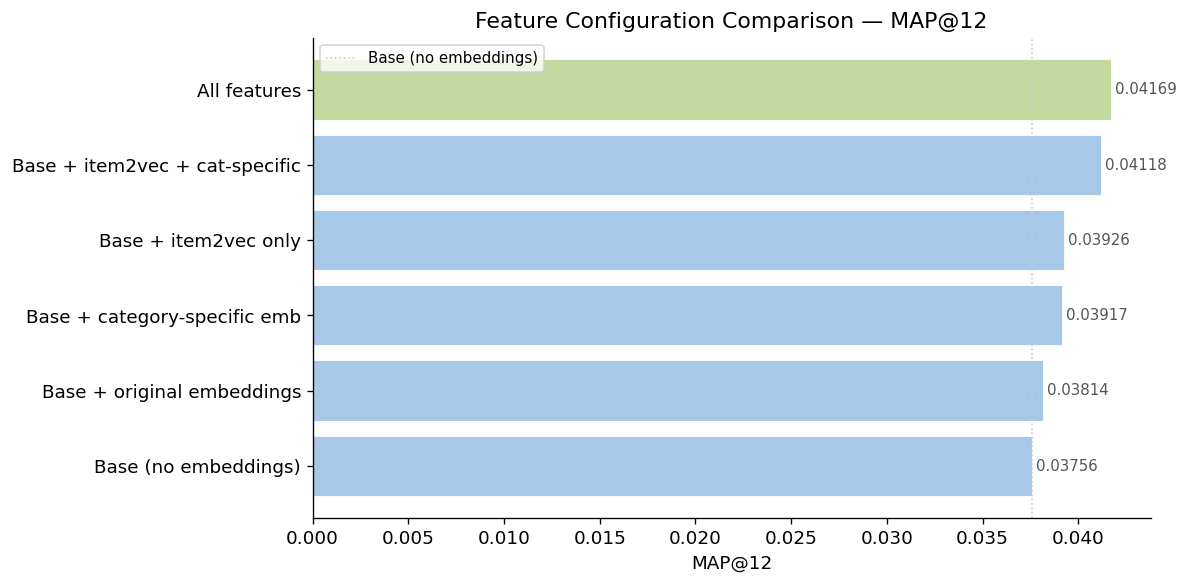

In [17]:
# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
sorted_r = sorted(config_results.items(), key=lambda x: x[1])
names = [r[0] for r in sorted_r]
scores = [r[1] for r in sorted_r]

colors = [PALETTE[2] if s == max(scores) else PALETTE[1] for s in scores]
bars = ax.barh(names, scores, color=colors, edgecolor='white', linewidth=0.5)
for bar, score in zip(bars, scores):
    ax.text(score + max(scores)*0.005, bar.get_y() + bar.get_height()/2,
            f'{score:.5f}', va='center', fontsize=9, color='#555')

ax.set_title('Feature Configuration Comparison — MAP@12')
ax.set_xlabel('MAP@12')
ax.axvline(base_score, color='#CCC', ls=':', lw=1, label='Base (no embeddings)')
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(FIG_DIR / 'feature_config_comparison.png', bbox_inches='tight')
plt.show()

In [18]:
# Feature importance for the best configuration
best_config_name = max(config_results, key=config_results.get)
best_feats = configs[best_config_name]
print(f"\nBest config: {best_config_name}")
print(f"Retraining for feature importance...")

_, best_model = train_and_score(best_config_name, best_feats)

imp = pd.DataFrame({
    'feature': best_feats,
    'importance': best_model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

print(f"\nTop 15 features:")
for _, row in imp.head(15).iterrows():
    is_new = " ★ NEW" if row['feature'] in new_features else ""
    print(f"  {row['feature']:30s} {row['importance']:>10.0f}{is_new}")


Best config: All features
Retraining for feature importance...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[118]	val's binary_logloss: 0.0223674

Top 15 features:
  item_pop_recent                     82155
  bought_any_variant                  42133
  img_sim_same_dept                   20780 ★ NEW
  user_days_since_last                20577
  item_pop_all                        20488
  copurchase_score                    18482
  item2vec_sim                        17834 ★ NEW
  item_pcode_pop                      16840
  als_score                           15862
  item_price                          14358
  text_sim_same_dept                  12455 ★ NEW
  user_std_price                      10840
  text_cosine_sim                     10787
  user_age                             9879
  img_cosine_sim                       9635


---
## 6. Save Updated Artifacts

In [19]:
# Save item2vec model
item2vec.save(str(OUT_DIR / 'item2vec.model'))

# Save updated pairs with new features
pairs_df.drop(columns=['_score'], errors='ignore').to_parquet(OUT_DIR / 'ranker_pairs_enhanced.parquet', index=False)

# Save config results
with open(OUT_DIR / 'config_results.pkl', 'wb') as f:
    pickle.dump(config_results, f)

print("✓ item2vec.model")
print("✓ ranker_pairs_enhanced.parquet")
print("✓ config_results.pkl")

✓ item2vec.model
✓ ranker_pairs_enhanced.parquet
✓ config_results.pkl


---
## Summary

**Item2Vec** learns behavioral item embeddings from purchase sequences — items
that are bought by similar customers in similar contexts get similar embeddings.
Unlike ResNet (visual) and sentence-transformers (textual), Item2Vec captures
what items mean *in terms of purchase behavior*.

**Category-specific embeddings** answer a more targeted question: "does this
blazer look like the blazers you've bought?" rather than "does this blazer
look like the average of your wardrobe."

Both extend the connection to Week 4's collaborative filtering content:
Item2Vec is essentially Word2Vec applied to purchase sequences — a neural
embedding approach to the same co-occurrence signal that item-based CF captures
with cosine similarity on the interaction matrix.